In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [4]:
# Load and parse data
df = pd.read_csv('output/primordial_system_prompt_options.csv')
df['num_lines'] = df['Prompt'].fillna('').apply(lambda x: len([l for l in x.split('\n') if l.strip()]))

# Filter to 1-4 lines only
df_filtered = df[(df['num_lines'] >= 1) & (df['num_lines'] <= 4)].copy()

In [5]:
# Prepare plot data
plot_data = []
plot_labels = []
plot_counts = []
plot_means = []

for n_lines in sorted(df_filtered['num_lines'].unique()):
    data = df_filtered[df_filtered['num_lines'] == n_lines]['silent'].values
    plot_data.append(data)
    plot_labels.append(str(n_lines))
    plot_counts.append(len(data))
    plot_means.append(np.mean(data))

# Color gradient
cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=0, vmax=100)
plot_colors = [cmap(norm(mean)) for mean in plot_means]

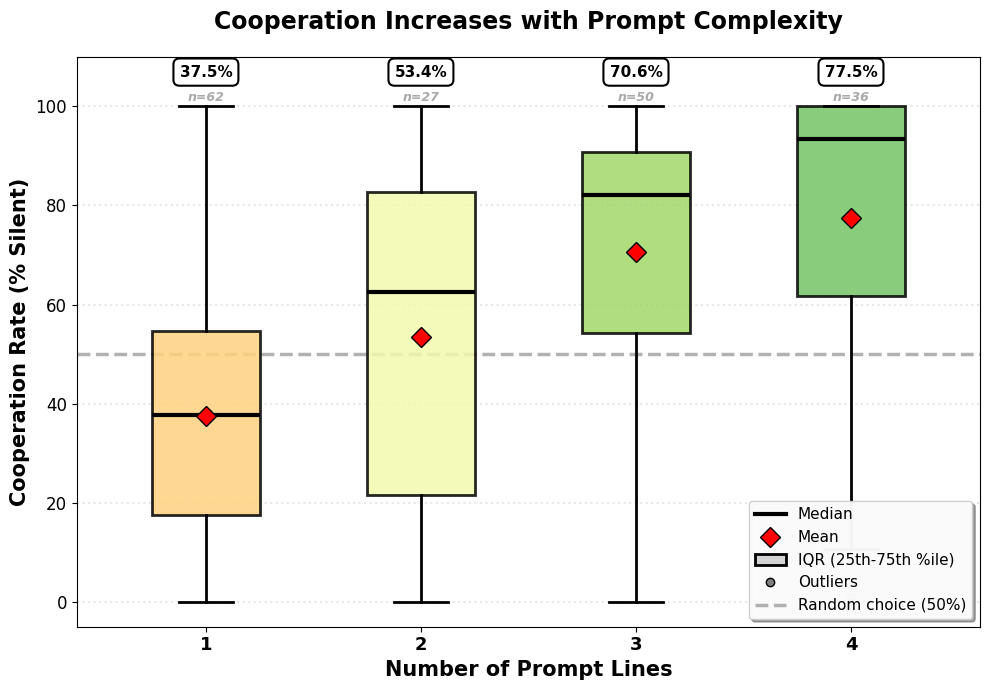

In [10]:
# Create box plot
fig, ax = plt.subplots(figsize=(10, 7))

positions = np.arange(len(plot_labels))
bp = ax.boxplot(plot_data, positions=positions, widths=0.5, patch_artist=True,
                showmeans=True, meanline=False,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=10, 
                              markeredgecolor='black', linewidth=1.5, zorder=3),
                boxprops=dict(linewidth=2),
                whiskerprops=dict(linewidth=2),
                capprops=dict(linewidth=2),
                medianprops=dict(color='black', linewidth=3),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=6, 
                               alpha=0.5, markeredgecolor='black', linewidth=1))

# Color boxes
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# Reference line and formatting
ax.axhline(y=50, color='gray', linestyle='--', linewidth=2.5, alpha=0.6, zorder=1)
ax.set_ylabel('Cooperation Rate (% Silent)', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Prompt Lines', fontsize=15, fontweight='bold')
ax.set_title('Cooperation Increases with Prompt Complexity', fontsize=17, fontweight='bold', pad=20)
ax.set_xticks(positions)
ax.set_xticklabels(plot_labels, fontsize=13, fontweight='bold')
ax.set_xlim(-0.6, len(plot_labels) - 0.4)
ax.set_ylim(-5, 110)
ax.set_yticks(np.arange(0, 101, 20))
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1.5)
ax.set_axisbelow(True)

# Add annotations
for i, (pos, mean, count) in enumerate(zip(positions, plot_means, plot_counts)):
    ax.text(pos, 106, f'{mean:.1f}%', ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', linewidth=1.5))
    ax.text(pos, 101, f'n={count}', ha='center', fontsize=9, style='italic', 
            color='darkgray', fontweight='bold')

# Legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0], [0], color='black', linewidth=3, label='Median'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='red', 
           markeredgecolor='black', markersize=10, linewidth=0, label='Mean'),
    Patch(facecolor='lightgray', edgecolor='black', linewidth=2, label='IQR (25th-75th %ile)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
           markeredgecolor='black', markersize=6, linewidth=0, label='Outliers'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2.5, alpha=0.6, label='Random choice (50%)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, frameon=True, 
          fancybox=True, shadow=True, framealpha=0.95)

plt.tight_layout()
plt.savefig('cooperation_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Summary statistics
print(f"{'Lines':<8} {'N':<6} {'Mean':<8} {'Median':<8} {'SD':<8} {'Min':<8} {'Max':<8}")
print("-" * 60)
for n_lines, data, mean in zip(plot_labels, plot_data, plot_means):
    print(f"{n_lines:<8} {len(data):<6} {mean:<8.1f} {np.median(data):<8.1f} {np.std(data):<8.1f} {np.min(data):<8.1f} {np.max(data):<8.1f}")

# Statistical tests
all_data = []
all_groups = []
for n_lines, data in zip(plot_labels, plot_data):
    all_data.extend(data)
    all_groups.extend([int(n_lines)] * len(data))

correlation, p_value = stats.spearmanr(all_groups, all_data)
h_stat, kw_p = stats.kruskal(*plot_data)

print(f"\nSpearman correlation: r={correlation:.3f}, p={p_value:.4f}")
print(f"Kruskal-Wallis H-test: H={h_stat:.2f}, p={kw_p:.4f}")

Lines    N      Mean     Median   SD       Min      Max     
------------------------------------------------------------
1        62     37.5     37.8     25.8     0.0      100.0   
2        27     53.4     62.5     34.3     0.0      100.0   
3        50     70.6     82.2     26.0     0.0      100.0   
4        36     77.5     93.4     31.5     0.0      100.0   

Spearman correlation: r=0.525, p=0.0000
Kruskal-Wallis H-test: H=48.22, p=0.0000
